# Mobile Price Classfication

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Load Data

In [2]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/mobile_price.csv')
print(df.shape)
df.head()

(2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## Data Preprocessing

In [3]:
# Cheak N/A value

print(df.isnull().sum())
print((df < 0).sum())
df.info()
df.describe()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


## SVM

### Calculate accuracy and F1-score of train_set / val_set / test_set

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Seperate features and target
X = df.drop('price_range',axis=1) #default axis=0 (row)
y = df['price_range']  # Catorgorical data (integer)

# Normalize the data to [0,1]
for col in X.columns:
    col_min = X[col].min()
    col_max = X[col].max()
    if col_max > col_min:
        X[col] = (X[col] - col_min) / (col_max - col_min)
    else:
        X[col] = 0.0

# Split 2 times
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # testset: 20%
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42) # trainset: 60%, validset: 20%

def SVM_training(X,y,C):
    svm_model = SVC(C=C, kernel='linear')
    svm_model.fit(X, y)
    return svm_model

def report_performance(model, X, y, name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred,average='weighted') # multiclass: None, macro, weighted, binary(default)
    print(f"{name} Set:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-score: {f1:.4f}")
    return acc, f1, name

svm_model = SVM_training(X_train, y_train,1)
report_performance(svm_model,X_train,y_train,'Train')
report_performance(svm_model,X_val,y_val,'Validation')
report_performance(svm_model,X_test,y_test,'Test')


Train Set:
  Accuracy: 0.9450
  F1-score: 0.9449
Validation Set:
  Accuracy: 0.9150
  F1-score: 0.9151
Test Set:
  Accuracy: 0.9625
  F1-score: 0.9626


(0.9625, 0.9625617599933214, 'Test')

### Calculate accuracy and F1-score of train_set / val_set / test_set with different penalty parameter

In [5]:
C_compare=[]
dataset={'train':[X_train,y_train],'val':[X_val,y_val],'test':[X_test,y_test]}
parameter = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

for c in np.array(parameter).astype(float):
    svm_model = SVM_training(X_train, y_train,c)
    print(f"---{c}---")
    for name, set in dataset.items():
        acc, f1, label= report_performance(svm_model,set[0],set[1], name)
        C_compare.append({'dataset':label,'accuracy':acc,'F1_score':f1,'C':c})
    print("")


---0.001---
train Set:
  Accuracy: 0.2625
  F1-score: 0.1092
val Set:
  Accuracy: 0.2325
  F1-score: 0.0877
test Set:
  Accuracy: 0.2300
  F1-score: 0.0860

---0.01---
train Set:
  Accuracy: 0.3267
  F1-score: 0.2173
val Set:
  Accuracy: 0.2950
  F1-score: 0.1938
test Set:
  Accuracy: 0.2675
  F1-score: 0.1549

---0.1---
train Set:
  Accuracy: 0.8817
  F1-score: 0.8833
val Set:
  Accuracy: 0.8600
  F1-score: 0.8627
test Set:
  Accuracy: 0.8725
  F1-score: 0.8751

---1.0---
train Set:
  Accuracy: 0.9450
  F1-score: 0.9449
val Set:
  Accuracy: 0.9150
  F1-score: 0.9151
test Set:
  Accuracy: 0.9625
  F1-score: 0.9626

---10.0---
train Set:
  Accuracy: 0.9750
  F1-score: 0.9750
val Set:
  Accuracy: 0.9350
  F1-score: 0.9350
test Set:
  Accuracy: 0.9850
  F1-score: 0.9850

---100.0---
train Set:
  Accuracy: 0.9858
  F1-score: 0.9858
val Set:
  Accuracy: 0.9600
  F1-score: 0.9598
test Set:
  Accuracy: 0.9675
  F1-score: 0.9676

---1000.0---
train Set:
  Accuracy: 0.9917
  F1-score: 0.9917
va

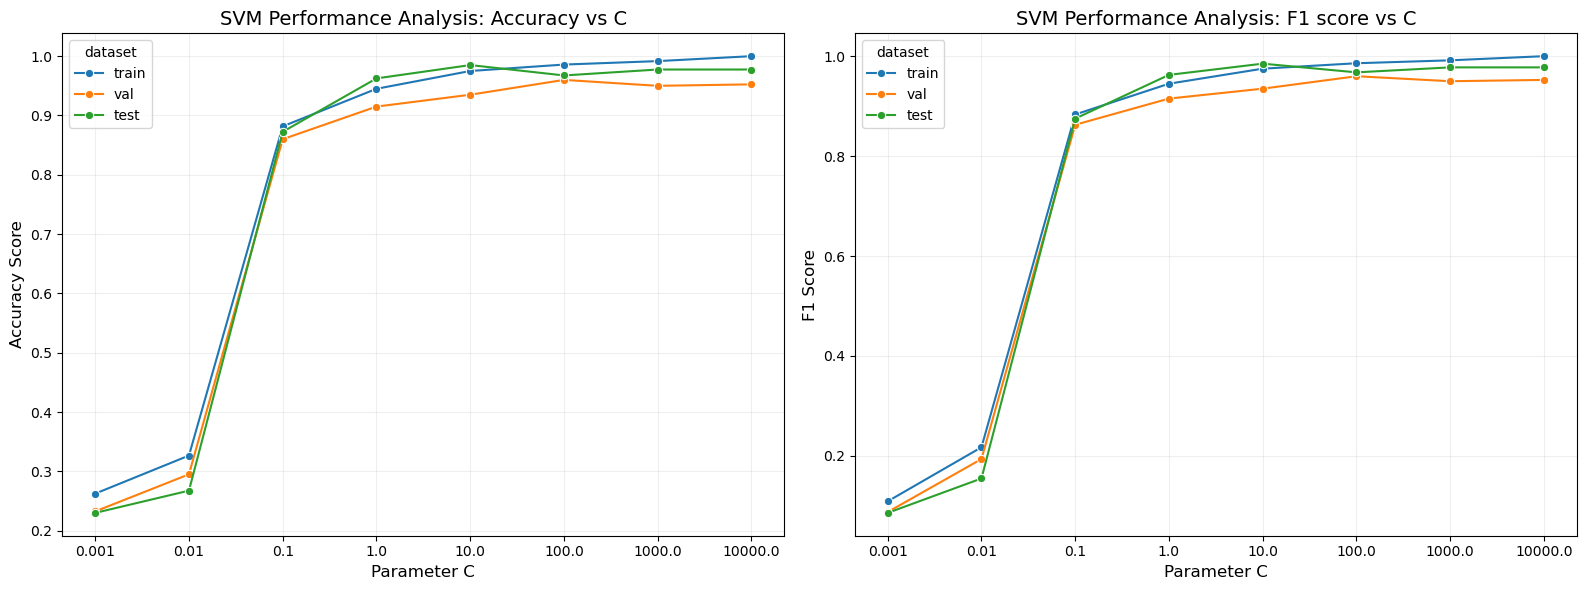

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

C_compare=pd.DataFrame(C_compare)
C_compare['C']=C_compare['C'].astype(str)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.lineplot(data=C_compare, x='C', y='accuracy', hue='dataset', marker='o',ax=ax1)

# Subplot 1
ax1.set_xlabel('Parameter C', fontsize=12)
ax1.set_ylabel('Accuracy Score', fontsize=12)
ax1.set_title('SVM Performance Analysis: Accuracy vs C', fontsize=14)
ax1.grid(True, which="both", ls="-", alpha=0.2)

# Subplot 2
sns.lineplot(data=C_compare, x='C', y='F1_score', hue='dataset', marker='o',ax=ax2)
ax2.set_xlabel('Parameter C', fontsize=12)
ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('SVM Performance Analysis: F1 score vs C', fontsize=14)
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

## FP-growth

### Preprocessing

In [7]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

# Capture feature
df_fp = df[df['price_range']==1]
df_fp = df_fp[['ram','int_memory','px_width','battery_power']]

# Divide into 3 categories: low, medium, high
def segement304030(df, column):
    col_max = max(df_fp[col])
    col_min = min(df_fp[col])
    col_range = col_max - col_min

    bin =[
        col_min - 0.001, # 0.001 - keep min
        col_min + col_range* 0.3, 
        col_min + col_range*0.7,
        col_max + 0.001  # 0.001 - keep max
    ]

    return pd.cut(df[column], bins=bin, labels=[f'{column}_low',f'{column}_medium',f'{column}_high'])

for col in df_fp.columns:
    df_fp[f'{col}_cat'] = segement304030(df_fp,col)

transactions = df_fp[['ram_cat','int_memory_cat','px_width_cat','battery_power_cat']].to_numpy().tolist()
print(transactions[0])

['ram_high', 'int_memory_low', 'px_width_low', 'battery_power_low']


In [8]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

# One-hot encoding
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_fp_encoded = pd.DataFrame(te_ary, columns=te.columns_)


### FP-growth


Support (Frequency) : how often an itemset is within the entire dataset
    * If the support of {A, B} is 0.1, it means that 10% of all transactions consist of both A and B.
    * Fliter out noise or rare occurrences
Confidence (Reliability) : How "sure" are we about the rule?
    * The likelihood that item B is purchased when item A is purchased (conditional probability =  P(B|A))
    * The strength of the rule
Lift (Correlation) : how much more likely item B is purchased given that item A is purchased
    * Lift > 1: Positive correlation. Item A actually "boosts" the sale of Item B.
    * Lift = 1: No correlation. A and B are independent.
    * Lift < 1: Negative correlation (Substitution effect). Buying A makes you less likely to buy B.


In [9]:
# Combination Frequency 

from mlxtend.frequent_patterns import fpgrowth

## Fliter support >= 0.3
frequent_itemsets = fpgrowth(df_fp_encoded, min_support=0.3, use_colnames=True) # min_support represent the combination must appear in at least how many % of the data
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

print(frequent_itemsets)


   support                                       itemsets
2    0.682                        frozenset({ram_medium})
3    0.416                   frozenset({px_width_medium})
5    0.414              frozenset({battery_power_medium})
4    0.412                 frozenset({int_memory_medium})
7    0.318  frozenset({battery_power_medium, ram_medium})
0    0.316                    frozenset({int_memory_low})
1    0.308                 frozenset({battery_power_low})
6    0.306       frozenset({ram_medium, px_width_medium})


In [15]:
# Find association rules
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="support", min_threshold=0.3)

## Condition 2 & 3：lift >= 0.8 and confidence >= 0.4
final_rules = rules[
    (rules['confidence'] >= 0.4) & 
    (rules['lift'] >= 0.8)
] 

print(final_rules.sort_values(by='lift', ascending=False))

                         antecedents                        consequents  \
0  frozenset({battery_power_medium})            frozenset({ram_medium})   
1            frozenset({ram_medium})  frozenset({battery_power_medium})   
2            frozenset({ram_medium})       frozenset({px_width_medium})   
3       frozenset({px_width_medium})            frozenset({ram_medium})   

   antecedent support  consequent support  support  confidence      lift  \
0               0.414               0.682    0.318    0.768116  1.126270   
1               0.682               0.414    0.318    0.466276  1.126270   
2               0.682               0.416    0.306    0.448680  1.078559   
3               0.416               0.682    0.306    0.735577  1.078559   

   representativity  leverage  conviction  zhangs_metric   jaccard  certainty  \
0               1.0  0.035652    1.371375       0.191319  0.408740   0.270805   
1               1.0  0.035652    1.097945       0.352557  0.408740   0.089208   


## PCA and K-means

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

X = df.drop('price_range',axis=1) #default axis=0 (row)
y = df['price_range']  # Catorgorical data (integer)

# Standardization
## prevent features with large magnitudes from dominating the analysis.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


### PCA
transforms a large set of variables into a smaller one that still contains most of the information from the large set.

In [52]:
from sklearn.decomposition import PCA
import pandas as pd

# Dimension reduction: PC1,PC2
## PC1: finds a straight line through the data that captures the largest amount of spread
## PC2: finds a second line, perpendicular to the first, that captures the next largest amount of spread.
pca = PCA(n_components=2)

# Projection  
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['price_range'] = y.values 

print(pca_df.head())

        PC1       PC2  price_range
0  0.323497 -2.616894            1
1 -1.998340  0.572836            2
2 -1.301465  0.190101            2
3 -1.149410 -0.274381            2
4  1.636494  1.291291            1


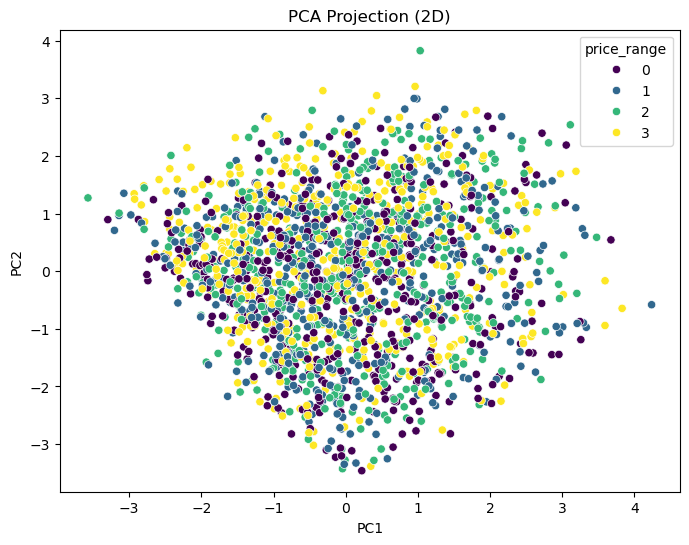

In [54]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='price_range', data=pca_df, palette='viridis')
plt.title('PCA Projection (2D)')
plt.show()

### K-means

In [ ]:
# With all features
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

kmeans = KMeans(n_clusters=4,random_state=42)
pca_df['kmeans_cluster_all'] =  kmeans.fit_predict(X_scaled)
ari_score = adjusted_rand_score(pca_df['price_range'], pca_df['kmeans_cluster_all']) #
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")

# print(pca_df.head())

Adjusted Rand Index (ARI): 0.0061


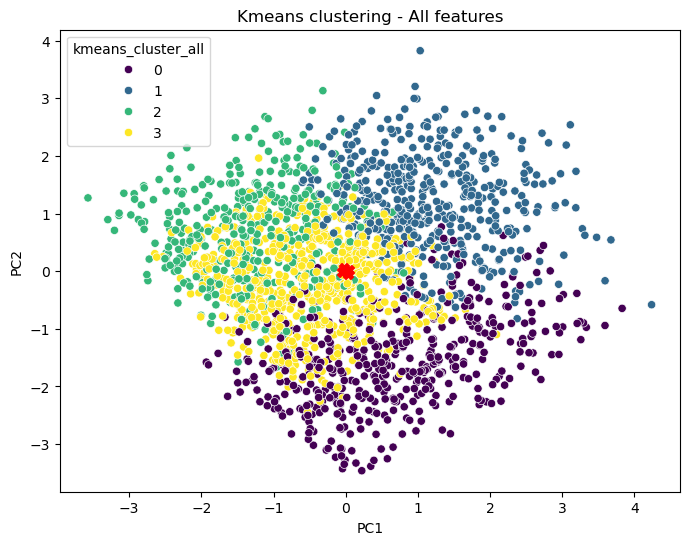

In [83]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='kmeans_cluster_all', data=pca_df, palette='viridis')
plt.title('Kmeans clustering - All features')
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=50, marker='X') # PC1 ,PC2
plt.show()

In [86]:
## With 2 PCA features
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

kmeans_2d = KMeans(n_clusters=4,random_state=42)
pca_df['kmeans_cluster_2d'] =  kmeans_2d.fit_predict(pca_df[['PC1','PC2']])
ari_score = adjusted_rand_score(pca_df['price_range'], pca_df['kmeans_cluster_2d'])
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")

# print(pca_df.head())

Adjusted Rand Index (ARI): 0.0004


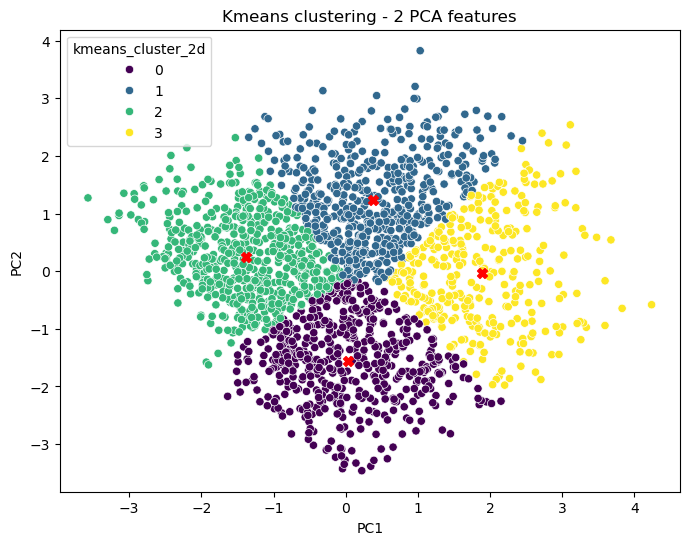

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='kmeans_cluster_2d', data=pca_df, palette='viridis')
plt.title('Kmeans clustering - 2 PCA features')
centroids = kmeans_2d.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=50, marker='X') # PC1 ,PC2
plt.show()